In [10]:
"""
plot_global_normalisation.py
------------------------------------------------------------------
Compute ONE global gain (target RMS) and ONE global μ/σ on the
whole bearing_thl_v1 corpus, then plot, for every *.csv file:

1) original signal               2) RMS‑scaled only
3) z‑score only                  4) RMS‑scaled + z‑score

Each figure is saved next to its CSV as <stem>_norm.png
Adjust TARGET_RMS, WINDOW_SEC, or GLOB as needed.
------------------------------------------------------------------
"""

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from brf_lightning.data.bearing.utils import load_vibration_data

# ---------------- user‑config ------------------------------------------------
ROOT      = Path("data/bearing_thl_v1")
TARGET_RMS = 1.0         # g
WINDOW_SEC = 1.0         # analyse first 1 s of each file
# -----------------------------------------------------------------------------

def first_window(fp: Path) -> tuple[np.ndarray, float]:
    df, fs = load_vibration_data(fp)
    return df["sensor_bearing"].to_numpy(np.float64)[: int(fs * WINDOW_SEC)], fs

# ------------------------------------------------------------------ #
# 1) gather global statistics (gain + μ/σ) over ALL files
# ------------------------------------------------------------------ #
signals, sample_rate = [], None
for csv in ROOT.glob("*.csv"):
    win, fs = first_window(csv)
    signals.append(win)
    sample_rate = fs

concat = np.concatenate(signals, dtype=np.float64)
rms_train = np.sqrt(np.mean(concat**2))
gain      = TARGET_RMS / (rms_train + 1e-12)

scaled = concat * gain
mu_g   = scaled.mean()
sigma_g = scaled.std(ddof=0)

print(f"Global stats  |  gain(G)={gain:.4f}   μ={mu_g:.4f}   σ={sigma_g:.4f}")

# ------------------------------------------------------------------ #
# 2) plot four‑pane figure for every file
# ------------------------------------------------------------------ #
for csv, raw in zip(ROOT.glob("*.csv"), signals):
    t = np.arange(raw.size) / sample_rate

    raw_rms  = raw * gain                        # only RMS
    raw_norm = (raw - raw.mean()) / (raw.std(ddof=0) + 1e-12)        # only z
    comb     = (raw_rms - mu_g) / (sigma_g + 1e-12)                  # both

    ymin = min(raw.min(), raw_rms.min(), raw_norm.min(), comb.min())
    ymax = max(raw.max(), raw_rms.max(), raw_norm.max(), comb.max())

    fig, ax = plt.subplots(4, 1, figsize=(10, 6), sharex=True, sharey=True)
    titles  = ["original", "RMS‑scaled only", "z‑score only", "RMS + z‑score"]
    for a, y, title in zip(ax, [raw, raw_rms, raw_norm, comb], titles):
        a.plot(t, y)
        a.set_title(f"{csv.stem}  |  {title}")
        a.set_xlim(t[0], t[-1])
        a.set_ylim(ymin, ymax)
        a.grid(True, ls="--", lw=0.3)
    ax[-1].set_xlabel("time  [s]")
    fig.tight_layout()
    out = ("notebooks/thesis/plots/normalization" / Path(csv.name)).with_suffix(".png")
    fig.savefig(out, dpi=150)
    plt.close(fig)
    print(f"saved → {out}")


Global stats  |  gain(G)=3.8388   μ=0.0036   σ=1.0000
saved → notebooks/thesis/plots/normalization/n20.png
saved → notebooks/thesis/plots/normalization/n10.png
saved → notebooks/thesis/plots/normalization/fIII20.png
saved → notebooks/thesis/plots/normalization/fAII10.png
saved → notebooks/thesis/plots/normalization/fIII30.png
saved → notebooks/thesis/plots/normalization/fAII30.png
saved → notebooks/thesis/plots/normalization/n30.png
saved → notebooks/thesis/plots/normalization/fIII10.png
saved → notebooks/thesis/plots/normalization/fAII20.png


GLOBAL statistics  — gain=3.8388,  μ=0.0036,  σ=1.0000


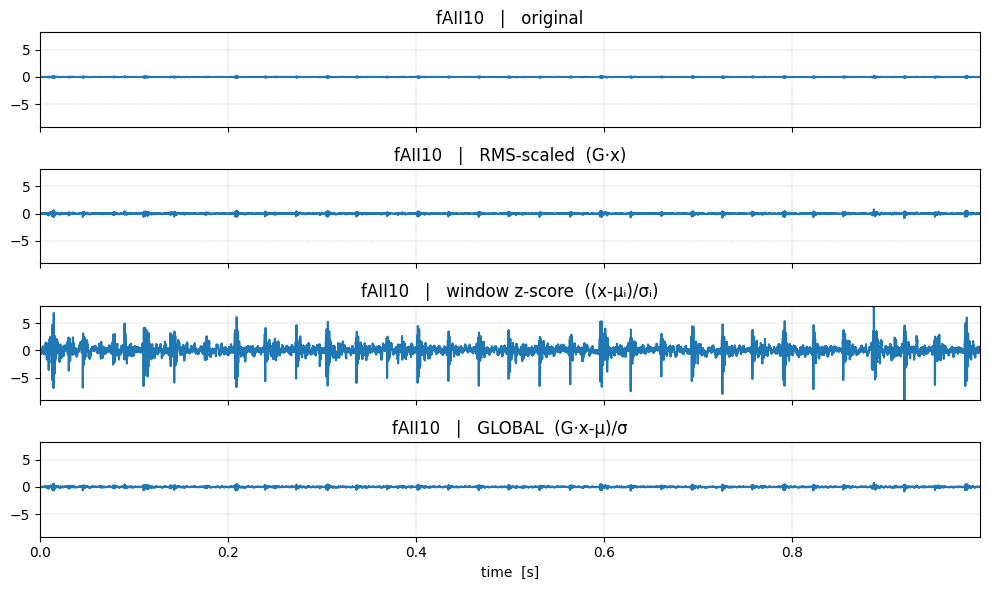

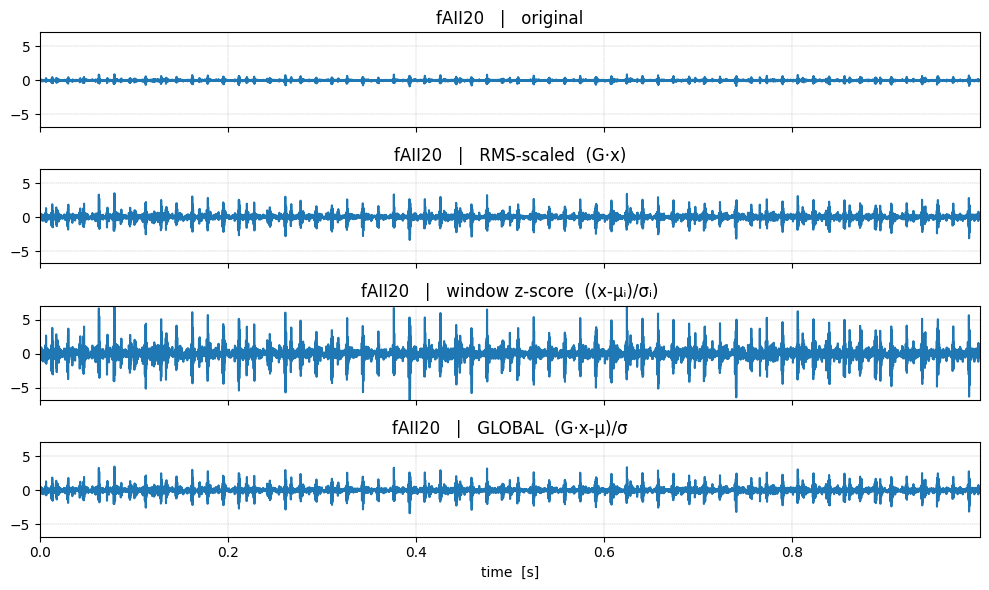

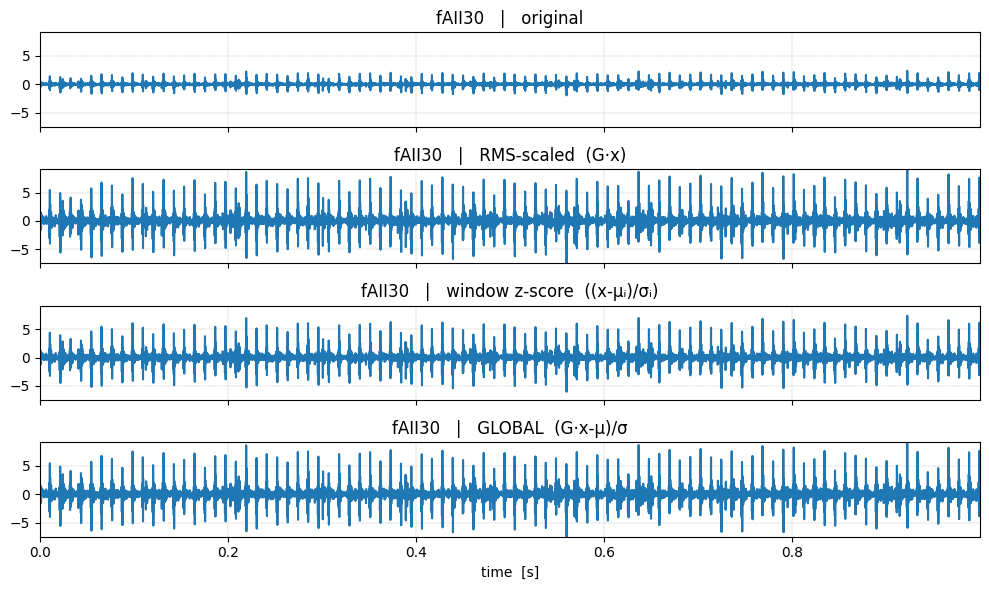

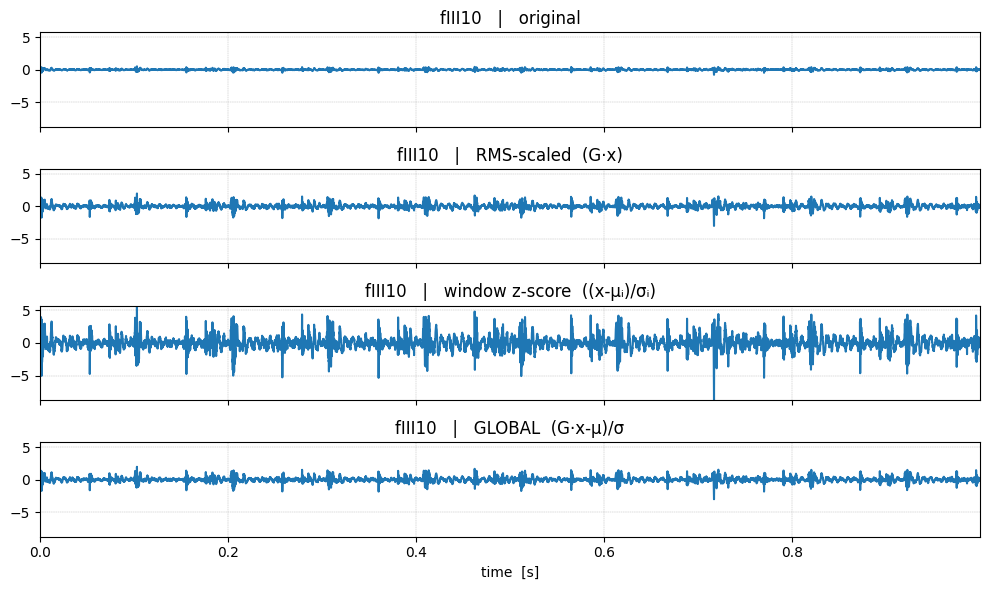

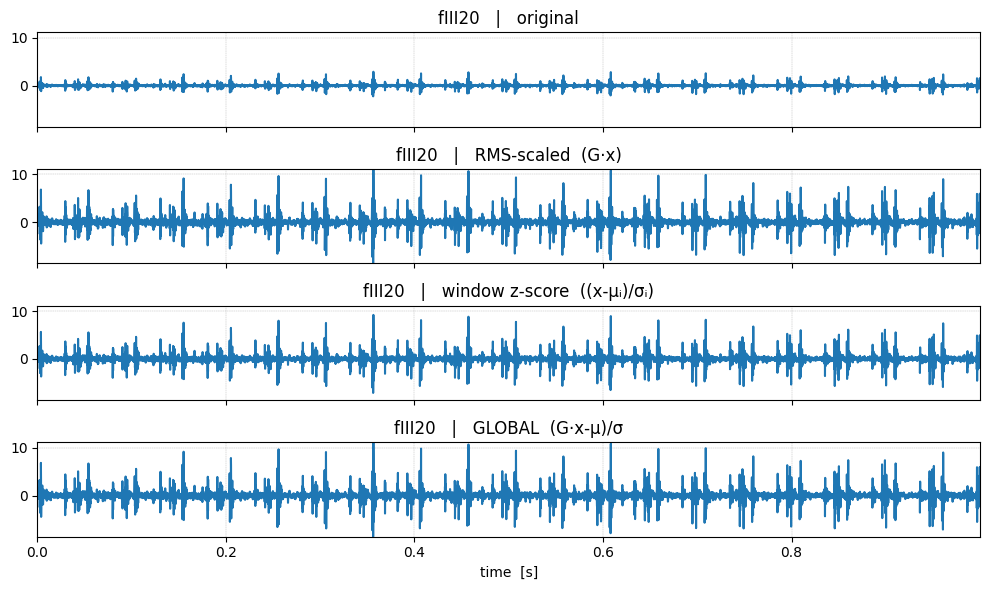

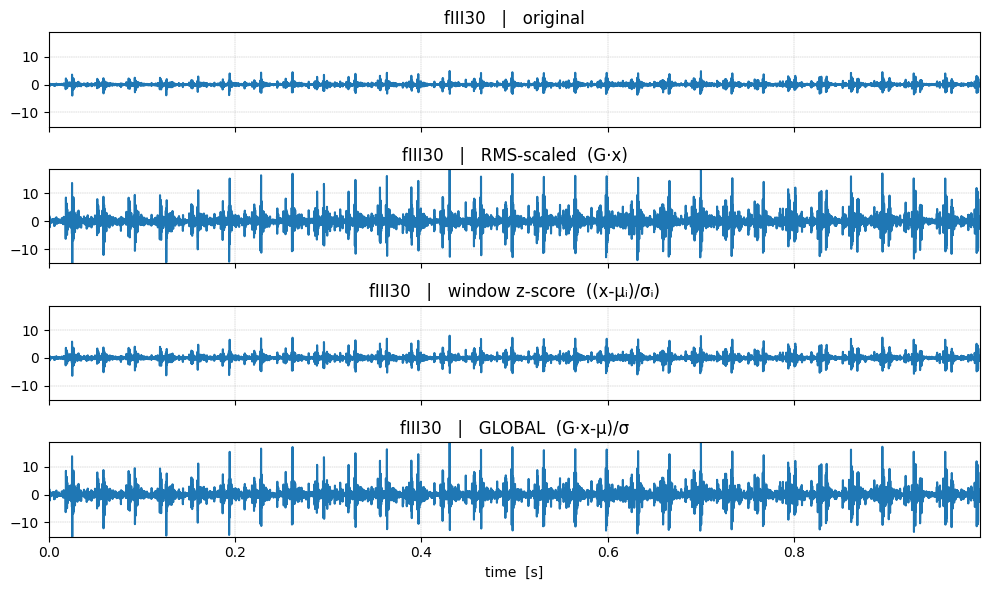

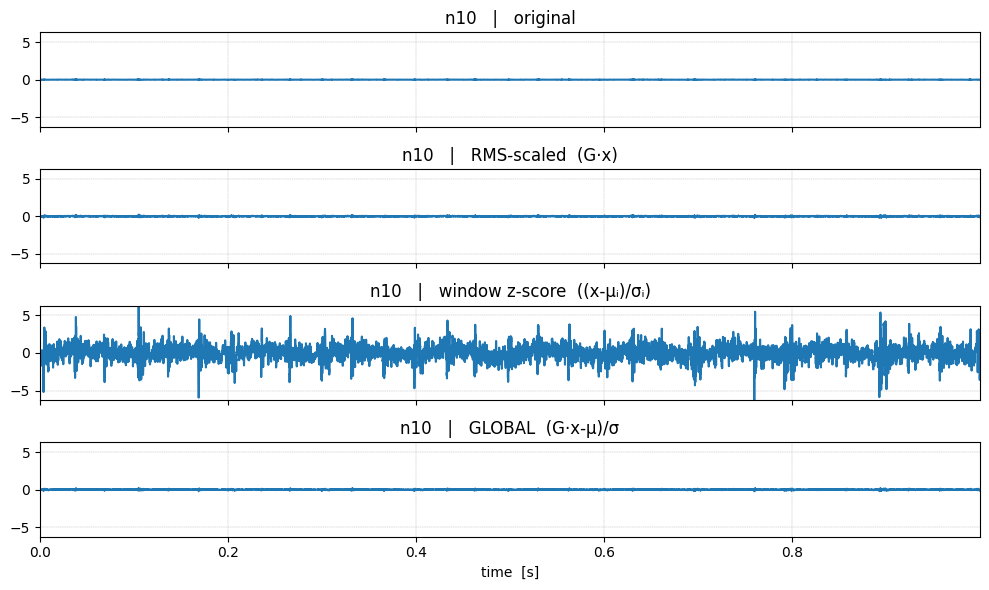

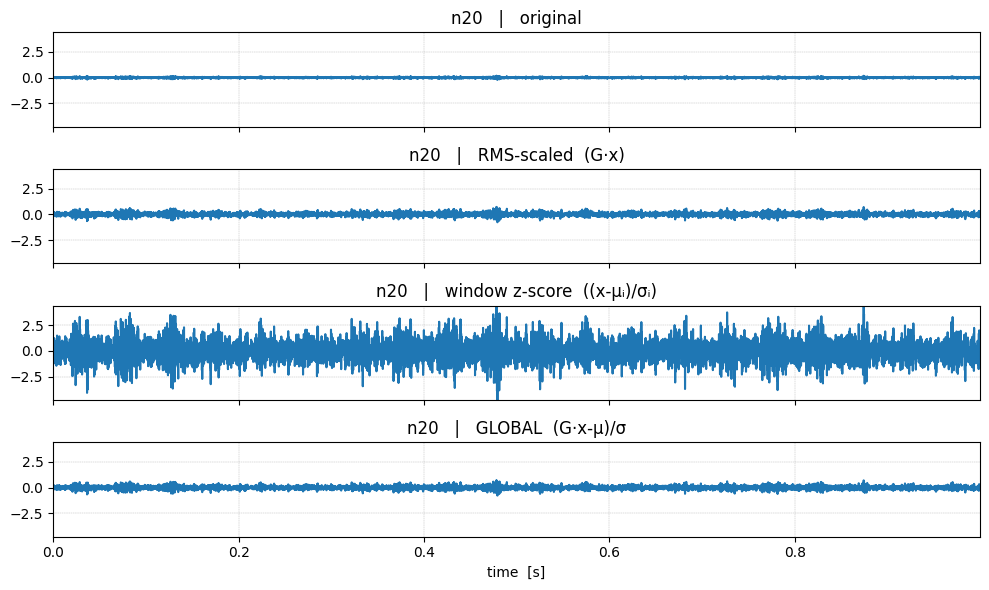

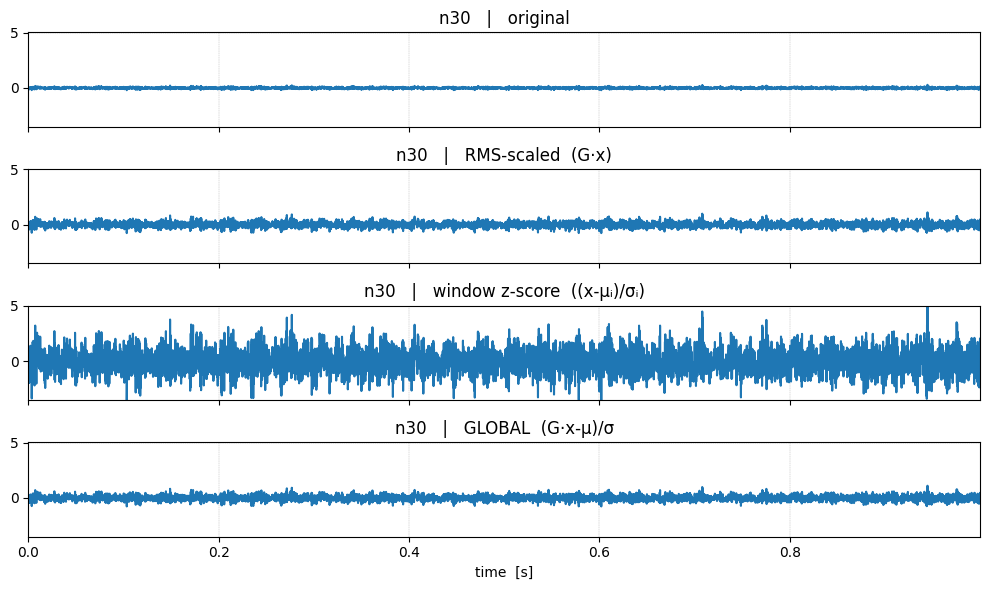

In [11]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from brf_lightning.data.bearing.utils import load_vibration_data

# ------------------------------------------------------------------
# USER SETTINGS ----------------------------------------------------
ROOT        = Path("data/bearing_thl_v1")   # folder with *.csv
TARGET_RMS  = 1.0                           # g   (global gain target)
WIN_SEC     = 1.0                           # seconds taken from each file
SAVE_PNG    = False                          # save <stem>_norm.png beside csv
# ------------------------------------------------------------------


def first_window(fp: Path, win_sec: float = WIN_SEC) -> tuple[np.ndarray, float]:
    """Return first window_sec of the bearing channel plus fs."""
    df, fs = load_vibration_data(fp)
    sig = df["sensor_bearing"].to_numpy(np.float64)[: int(fs * win_sec)]
    return sig, fs


# 1) COLLECT ALL WINDOWS ----------------------------------------------------
windows, fs_holder = [], None
for csv in sorted(ROOT.glob("*.csv")):
    w, fs = first_window(csv, WIN_SEC)
    windows.append(w)
    fs_holder = fs

all_raw = np.concatenate(windows, dtype=np.float64)

# 2) GLOBAL GAIN  (single scalar) -------------------------------------------
rms_train = np.sqrt(np.mean(all_raw ** 2))
gain      = TARGET_RMS / (rms_train + 1e-12)

all_scaled = all_raw * gain

# 3) GLOBAL μ / σ AFTER GAIN  -----------------------------------------------
mu_g   = all_scaled.mean()
sigma_g = all_scaled.std(ddof=0)

print(f"GLOBAL statistics  — gain={gain:.4f},  μ={mu_g:.4f},  σ={sigma_g:.4f}")

# 4) PER‑FILE PLOTS ----------------------------------------------------------
for csv, raw in zip(sorted(ROOT.glob("*.csv")), windows):
    t = np.arange(raw.size) / fs_holder

    # transforms
    rms_scaled = raw * gain
    win_mu, win_sigma = raw.mean(), raw.std(ddof=0)
    win_z      = (raw - win_mu) / (win_sigma + 1e-12)          # per‑window z‑score
    comb       = (rms_scaled - mu_g) / (sigma_g + 1e-12)       # global gain + z‑score

    # collect y‑lims so visual scale identical across four panes of THIS file
    y_min = min(raw.min(), rms_scaled.min(), win_z.min(), comb.min())
    y_max = max(raw.max(), rms_scaled.max(), win_z.max(), comb.max())

    fig, ax = plt.subplots(4, 1, figsize=(10, 6), sharex=True, sharey=True)
    variants = [
        (raw,        "original"),
        (rms_scaled, "RMS‑scaled  (G·x)"),
        (win_z,      "window z‑score  ((x-μᵢ)/σᵢ)"),
        (comb,       "GLOBAL  (G·x-μ)/σ")
    ]

    for a, (sig, title) in zip(ax, variants):
        a.plot(t, sig)
        a.set_title(f"{csv.stem}   |   {title}")
        a.set_xlim(t[0], t[-1])
        a.set_ylim(y_min, y_max)
        a.grid(True, ls="--", lw=0.3)

    ax[-1].set_xlabel("time  [s]")
    fig.tight_layout()

    if SAVE_PNG:
        out = csv.with_suffix("_norm.png")
        fig.savefig(out, dpi=150)
        print("saved →", out)
    else:
        plt.show()

plt.close("all")


In [ ]:
"""
compare_rms_vs_zscore.py
----------------------------------------------------------
Visualise, for EVERY *.csv in data/bearing_thl_v1:

1) original signal
2) global‑RMS gain only   (G·x)
3) window‑z‑score only    ((x‑μᵢ)/σᵢ)
4) global (G·x‑μ)/σ

Each transform keeps its *own* y‑axis so amplitude
differences are visible.  One PNG per file is written
next to the CSV as  <stem>_norm.png.
"""

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from brf_lightning.data.bearing.utils import load_vibration_data


ROOT       = Path("data/bearing_thl_v1")
TARGET_RMS = 1.0        # g
WIN_SEC    = 1.0        # seconds per file


def first_window(fp: Path) -> tuple[np.ndarray, float]:
    df, fs = load_vibration_data(fp)
    return df["sensor_bearing"].to_numpy(np.float64)[: int(fs * WIN_SEC)], fs


# ------------------------------------------------------------
# 1) GLOBAL gain + μ/σ (computed over ALL files)
# ------------------------------------------------------------
windows, fs = [], None
for csv in ROOT.glob("*.csv"):
    w, fs = first_window(csv)
    windows.append(w)

all_raw     = np.concatenate(windows)
rms_train   = np.sqrt(np.mean(all_raw**2))
gain        = TARGET_RMS / (rms_train + 1e-12)
all_scaled  = all_raw * gain
mu_g        = all_scaled.mean()
sigma_g     = all_scaled.std(ddof=0)

print(f"GLOBAL  gain={gain:.4f},  μ={mu_g:.4f},  σ={sigma_g:.4f}")

# ------------------------------------------------------------
# 2) per‑file plots, each subplot with its own y‑limits
# ------------------------------------------------------------
for csv, raw in zip(sorted(ROOT.glob("*.csv")), windows):
    t          = np.arange(raw.size) / fs
    rms_scaled = raw * gain
    mu_i, sig_i = raw.mean(), raw.std(ddof=0)
    win_z      = (raw - mu_i) / (sig_i + 1e-12)
    comb       = (rms_scaled - mu_g) / (sigma_g + 1e-12)

    fig, ax = plt.subplots(4, 1, figsize=(9, 7), sharex=True, sharey=False)
    variants = [
        (raw,        "original"),
        (rms_scaled, "RMS‑only (G·x)"),
        (win_z,      "window z‑score ((x‑μᵢ)/σᵢ)"),
        (comb,       "GLOBAL (G·x‑μ)/σ"),
    ]

    for a, (sig, title) in zip(ax, variants):
        a.plot(t, sig)
        a.set_title(f"{csv.stem}   |   {title}")
        a.grid(True, ls="--", lw=0.3)

    ax[-1].set_xlabel("time  [s]")
    fig.tight_layout()
    out = csv.with_suffix("_norm.png")
    fig.savefig(out, dpi=150)
    plt.close(fig)
    print("saved →", out)
